<a href="https://colab.research.google.com/github/TonicAI/cookbooks/blob/main/sft/clinical_conversations/fabricate_fireworks_transcript_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zero-label fine-tuning with synthetic conversations

Training an extraction model normally means labeling transcripts — slowly, expensively, and least reliably exactly where it matters most: negation ("no chest pain"), family history ("my mother had heart failure"), medication changes ("I stopped taking it last week"). When the transcripts are clinical, they're also PHI, so often you can't label them at all.

[Tonic Fabricate](https://fabricate.tonic.ai) inverts the problem. Instead of writing conversations and then labeling them, it authors the **structured facts first** — as relational data with controlled vocabularies and per-fact directives — and renders the conversation *from* those facts. The extraction target is then a deterministic projection of the fact tables: **no model ever writes a label**, and every fact carries an evidence quote that is an exact substring of the dialogue.

Does that data actually teach a small model the task? That's an empirical question, so we measure it — at three data sizes, against a frontier-class bar:

| contender | trains on | shows |
|---|---|---|
| Qwen3-4B, zero-shot | — | why fine-tune at all |
| Qwen3-4B + **300 / 600 / 900** synthetic conversations | structure-first synthetic data | the zero-label pipeline, and how it scales |
| gpt-oss-120B, zero-shot | — | the frontier-class bar |

If the tuned 4B reaches the 120B bar, task-specific extraction gets roughly 30× cheaper to serve.

## Generating the data in Fabricate

Fabricate's agent builds datasets from a natural-language **generation contract**: you describe the tables, the vocabularies, the realism requirements, and the quality gates; it authors the relational scenario data, renders the dialogue, links the evidence, and self-audits before exporting. The contract behind this dataset, condensed:

```text
Generate clinical-conversation scenarios as relational data, then render each
as free-prose dialogue.

SCENARIO FACTS — author rows in controlled-vocabulary tables (conditions,
symptoms, medications, measurements, care-plan items, escalations). Every fact
carries a directive: explicit | indirect | omitted | corrected — plus a
distractor flag for third-party facts that must appear in dialogue but never
in the target.

DIALOGUE — render as free prose, one conversation at a time: 8–40 utterances,
varied openings and registers, patient rambling and self-repairs, facts
realized out of order. Templated or slot-filled rendering is forbidden,
audited by skeleton deduplication: normalize numbers and clinical entities
out of each utterance and require <30% of utterances to share a recurring
skeleton.

REALIZATION — every non-omitted fact is spoken at its authored specificity:
formal diagnosis terms said at least once, measurement values said aloud,
medication dose/unit/frequency/adherence ≥95% spoken, symptom severity and
onset ≈80%. Attributes the dialogue doesn't state stay NULL. Negated facts
make up ≈10% of conditions+symptoms, phrased as varied natural denials.

EVIDENCE — every non-omitted fact links to an exact-substring quote from one
utterance, written at insert time.

SELF-CHECK — before export, report: evidence substring failures (0), enum
violations (0), omitted-fact leaks (0), skeleton-duplication share, attribute
densities, and coverage against targets.
```

The same contract runs for training and evaluation data, with one deliberate asymmetry: the evaluation split is rendered by a **different model family** than train, so the learning curve measures the task rather than one renderer's style. A challenge split adds 25 counterfactual minimal-pair families — the same conversation twice, with exactly one clinical fact flipped.

We've published the output of this process as [TonicAI/synthetic_clinical_conversations](https://huggingface.co/datasets/TonicAI/synthetic_clinical_conversations) — 600 fully synthetic encounters, each in a clean and an ASR-noisy variant, with per-fact evidence and the distractor/omitted trap metadata. **The rest of this notebook starts from that dataset**, so everything below runs without a Fabricate account; to build the same thing for your own domain, the contract above is the template.

## Setup

You'll need:

- `FIREWORKS_API_KEY` and your account id — from [fireworks.ai](https://fireworks.ai)

**Running on Colab:** add `FIREWORKS_API_KEY` and `FIREWORKS_ACCOUNT_ID` in the Secrets panel (the 🔑 icon) and grant this notebook access; locally, export them as environment variables. The default CPU runtime is fine — fine-tuning and inference run on Fireworks infrastructure.

A cost note before running end-to-end: the three fine-tuning jobs bill per training token (a few dollars at these defaults), and evaluation uses a dedicated GPU deployment billed per GPU-second while it exists — the cleanup cell at the end deletes it.

In [1]:
%pip install -q --pre fireworks-ai datasets pandas tqdm matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import re
import time
import concurrent.futures as cf
from collections import Counter
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from tqdm.auto import tqdm

from fireworks import Fireworks, NotFoundError

# Credentials — works on Colab (Secrets panel) and locally (environment variables).
def load_secret(name):
    if os.environ.get(name):
        return os.environ[name]
    try:  # Colab: read from the Secrets panel (key icon in the left sidebar)
        from google.colab import userdata
        value = userdata.get(name)
    except Exception:  # anywhere else: prompt once, without echoing
        from getpass import getpass
        value = getpass(f"{name}: ")
    os.environ[name] = value
    return value

load_secret("FIREWORKS_API_KEY")
FIREWORKS_ACCOUNT = load_secret("FIREWORKS_ACCOUNT_ID")

fw = Fireworks(account_id=FIREWORKS_ACCOUNT)

STUDENT = "accounts/fireworks/models/qwen3-4b-instruct-2507"
ANCHOR = "accounts/fireworks/models/gpt-oss-120b"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## 1. Load the conversations

In [3]:
ds = load_dataset("TonicAI/synthetic_clinical_conversations")
ds

DatasetDict({
    train: Dataset({
        features: ['example_id', 'scenario_id', 'variant', 'transcript', 'utterances', 'target', 'evidence', 'clinical_domain', 'encounter_type', 'difficulty_tier', 'distractor_names', 'omitted_names', 'noise_features'],
        num_rows: 900
    })
    validation: Dataset({
        features: ['example_id', 'scenario_id', 'variant', 'transcript', 'utterances', 'target', 'evidence', 'clinical_domain', 'encounter_type', 'difficulty_tier', 'distractor_names', 'omitted_names', 'noise_features'],
        num_rows: 200
    })
    challenge: Dataset({
        features: ['example_id', 'scenario_id', 'variant', 'transcript', 'utterances', 'target', 'evidence', 'clinical_domain', 'encounter_type', 'difficulty_tier', 'distractor_names', 'omitted_names', 'noise_features'],
        num_rows: 100
    })
})

In [4]:
example = ds["validation"][2]
print(example["transcript"][:900], "…")
print("\n--- target (excerpt) ---")
print(json.dumps({k: example["target"][k] for k in ("medications", "symptoms")}, indent=1)[:800])

ADVANCED_PRACTICE_CLINICIAN: Hi Coralen, how are you doing today? I'm calling to check in on how things have been going with your medications and, you know, just the general check-in we had scheduled.
PATIENT: Oh hey, thanks for calling. I'm... honestly I've been a little weird lately. Like, I had this weird feeling in my throat about three weeks ago, kind of lightheaded-ish, not dizzy exactly, but like a sharp feeling right here when I swallow sometimes.
ADVANCED_PRACTICE_CLINICIAN: Okay, so that sharp feeling started three weeks ago. Is it still happening now, or has that improved?
PATIENT: Yeah, it's way better now, actually. Like it was pretty rough for a few days there, but it's definitely improving. My roommate had the flu like a week ago and I was terrified I was gonna get it, and then I started feeling that throat thing and just panicked, you know?
ADVANCED_PRACTICE_CLINICIAN: I  …

--- target (excerpt) ---
{
 "medications": [
  {
   "name": "metoprolol",
   "dose": "25",
   "u

Every fact in the target is backed by evidence — a quote guaranteed to be an exact substring of a specific utterance. That guarantee is what makes the labels auditable rather than asserted:

In [5]:
utterance_text = {u["utterance_id"]: u["text"] for u in example["utterances"]}
for ev in example["evidence"][:5]:
    assert ev["quote"] in utterance_text[ev["utterance_id"]]
    print(f'{ev["fact_id"]:>14}  “{ev["quote"]}”')
print("… every quote resolves.")

     v0003-c01  “Much better. But then like yesterday I was thinking, what if I'm getting pneumonia instead? I know that sounds dramatic but I've been coughing a little bit and just... I don't know, I'm worried about it.”
     v0003-c02  “Yeah, it's way better now, actually. Like it was pretty rough for a few days there, but it's definitely improving. My roommate had the flu like a week ago and I was terrified I was gonna get it, and then I started feeling that throat thing and just panicked, you know?”
    v0003-sy01  “Okay, so you're having some cough and you're concerned about pneumonia. Let me ask you a few things—are you running a fever at all? And are you having any dizziness or anything like that?”
    v0003-sy02  “Oh hey, thanks for calling. I'm... honestly I've been a little weird lately. Like, I had this weird feeling in my throat about three weeks ago, kind of lightheaded-ish, not dizzy exactly, but like a sharp feeling right here when I swallow sometimes.”
     v0003-m01  “

## 2. Verify, don't trust

Synthetic labels are only worth training on if three properties hold, and all three are machine-checkable in a few lines: the labels are **grounded** (every evidence quote resolves exactly), the dialogue is **diverse** (not template-generated — we normalize numbers and clinical entities out of each utterance and count duplicate "skeletons"), and the splits are **distribution-matched** (a model trained on train meets the same label conventions in validation).

In [6]:
# grounded: every evidence quote is an exact substring (evidence anchors the
# clean rendering of each scenario; noisy variants share the same facts)
bad = total = 0
for split in ds:
    for ex in ds[split]:
        if ex["variant"] != "clean":
            continue
        texts = {u["utterance_id"]: u["text"] for u in ex["utterances"]}
        bad += sum(ev["quote"] not in texts.get(ev["utterance_id"], "") for ev in ex["evidence"])
        total += len(ex["evidence"])
print(f"evidence quotes failing exact-substring check: {bad} of {total}")

# diverse: share of utterances whose normalized skeleton recurs ≥3 times
entity_words = set()
for ex in ds["train"]:
    for section in ("conditions", "symptoms", "medications"):
        for fact in ex["target"][section]:
            entity_words.update(re.findall(r"[a-z]+", fact["name"].lower()))

def skeleton_dup_share(split):
    skeletons = Counter()
    for ex in ds[split]:
        if ex["variant"] != "clean":
            continue
        for u in ex["utterances"]:
            tokens = re.findall(r"[a-z']+|\d+", u["text"].lower())
            skel = " ".join("#" if t[0].isdigit() else ("@" if t in entity_words else t) for t in tokens)
            skeletons[skel] += 1
    total = sum(skeletons.values())
    return sum(n for n in skeletons.values() if n >= 3) / total

for split in ds:
    print(f"{split}: {skeleton_dup_share(split):.1%} duplicate-skeleton share")

# matched: per-attribute non-null density, train vs validation
def density(split, section, attr):
    vals = [f[attr] for ex in ds[split] if ex["variant"] == "clean" for f in ex["target"][section]]
    return sum(v is not None for v in vals) / len(vals)

rows = {}
for section, attr in [("medications", "dose"), ("medications", "unit"), ("medications", "frequency"), ("medications", "adherence")]:
    rows[f"{section}.{attr}"] = {s: round(density(s, section, attr), 2) for s in ("train", "validation")}
pd.DataFrame(rows).T

evidence quotes failing exact-substring check: 0 of 6847
train: 1.0% duplicate-skeleton share
validation: 0.0% duplicate-skeleton share
challenge: 0.0% duplicate-skeleton share


,train,validation
medications.dose,0.99,1.0
medications.unit,1.00,1.0
medications.frequency,1.00,1.0
medications.adherence,1.00,1.0


## 3. Define the extraction task

The target is one typed record per conversation, with controlled vocabularies for every categorical field. The Pydantic model does double duty: it documents the schema inside the system prompt, and at evaluation time it validates model outputs.

In [7]:
from enum import Enum
from typing import List, Optional

from pydantic import BaseModel

class Assertion(str, Enum):
    PRESENT = "present"; ABSENT = "absent"; SUSPECTED = "suspected"
    CONDITIONAL = "conditional"; RESOLVED = "resolved"; UNKNOWN = "unknown"

class Temporality(str, Enum):
    CURRENT = "current"; HISTORICAL = "historical"
    FUTURE_OR_PLANNED = "future_or_planned"; UNKNOWN = "unknown"

class Experiencer(str, Enum):
    PATIENT = "patient"; FAMILY_MEMBER = "family_member"; OTHER = "other"; UNKNOWN = "unknown"

class Severity(str, Enum):
    MILD = "mild"; MODERATE = "moderate"; SEVERE = "severe"

class Trend(str, Enum):
    IMPROVING = "improving"; WORSENING = "worsening"; STABLE = "stable"

class MedStatus(str, Enum):
    CURRENT = "current"; STOPPED = "stopped"; HELD = "held"
    PLANNED = "planned"; HISTORICAL = "historical"; UNKNOWN = "unknown"

class MedAction(str, Enum):
    START = "start"; CONTINUE = "continue"; INCREASE = "increase"; DECREASE = "decrease"
    STOP = "stop"; HOLD = "hold"; REFILL = "refill"; RESUME = "resume"; NONE = "none"; UNKNOWN = "unknown"

class Adherence(str, Enum):
    ADHERENT = "adherent"; MISSED_DOSES = "missed_doses"; NOT_TAKING = "not_taking"; UNKNOWN = "unknown"

class ReportedBy(str, Enum):
    PATIENT_REPORTED = "patient_reported"; CLINICIAN_VERIFIED = "clinician_verified"

class CarePlanActionType(str, Enum):
    APPOINTMENT = "appointment"; LAB_ORDER = "lab_order"; MEDICATION_CHANGE = "medication_change"
    MONITORING = "monitoring"; LIFESTYLE = "lifestyle"; REFERRAL = "referral"

class Condition(BaseModel):
    name: str
    assertion: Assertion
    temporality: Temporality
    experiencer: Experiencer

class Symptom(BaseModel):
    name: str
    assertion: Assertion
    severity: Optional[Severity] = None
    onset: Optional[str] = None
    duration: Optional[str] = None
    trend: Optional[Trend] = None
    location: Optional[str] = None

class Medication(BaseModel):
    name: str
    dose: Optional[str] = None
    unit: Optional[str] = None
    route: Optional[str] = None
    frequency: Optional[str] = None
    status: MedStatus
    action: MedAction
    adherence: Optional[Adherence] = None

class Measurement(BaseModel):
    name: str
    value: str
    unit: Optional[str] = None
    reported_by: ReportedBy

class FollowUp(BaseModel):
    action_type: CarePlanActionType
    description: str
    responsible_party: Optional[str] = None
    timing: Optional[str] = None
    committed: bool

class EscalationFlag(BaseModel):
    reason: str
    destination: Optional[str] = None

class EncounterRecord(BaseModel):
    encounter_type: str
    chief_concerns: List[str]
    conditions: List[Condition]
    symptoms: List[Symptom]
    medications: List[Medication]
    measurements: List[Measurement]
    follow_up: List[FollowUp]
    escalation_flags: List[EscalationFlag]

In [8]:
SYSTEM_PROMPT = """You are Clinical-Conversation-Extractor v1.
Read a speaker-labeled transcript of a clinical conversation and emit ONLY a compact JSON object validating against this Pydantic schema:

```python
class Condition(BaseModel):
    name: str                       # lowercase clinical term as normalized from the transcript
    assertion: str                  # present | absent | suspected | conditional | resolved | unknown
    temporality: str                # current | historical | future_or_planned | unknown
    experiencer: str                # patient | family_member | other | unknown

class Symptom(BaseModel):
    name: str
    assertion: str
    severity: Optional[str]         # "mild"|"moderate"|"severe", ONLY if stated
    onset: Optional[str]            # ONLY if stated, e.g. "three weeks ago"
    duration: Optional[str]         # ONLY if stated
    trend: Optional[str]            # "improving"|"worsening"|"stable", ONLY if stated
    location: Optional[str]         # ONLY if stated

class Medication(BaseModel):
    name: str                       # generic name, lowercase
    dose: Optional[str]             # e.g. "20"
    unit: Optional[str]             # e.g. "mg"
    route: Optional[str]            # "oral"|"inhaled"|"injection"|"topical"
    frequency: Optional[str]        # e.g. "once daily"
    status: str                     # current | stopped | held | planned | historical | unknown
    action: str                     # start | continue | increase | decrease | stop | hold | refill | resume | none | unknown
    adherence: Optional[str]        # adherent | missed_doses | not_taking | unknown

class Measurement(BaseModel):
    name: str                       # e.g. "blood pressure"
    value: str                      # e.g. "142/90"
    unit: Optional[str]
    reported_by: str                # patient_reported | clinician_verified

class FollowUp(BaseModel):
    action_type: str                # appointment | lab_order | medication_change | monitoring | lifestyle | referral
    description: str
    responsible_party: Optional[str]
    timing: Optional[str]
    committed: bool                 # true ONLY if the conversation commits to it

class EscalationFlag(BaseModel):
    reason: str
    destination: Optional[str]

class EncounterRecord(BaseModel):
    encounter_type: str             # routine_followup | symptom_report | medication_adherence | medication_question_or_refill | medication_reconciliation | results_review | post_discharge_checkin | followup_scheduling | escalation
    chief_concerns: List[str]
    conditions: List[Condition]
    symptoms: List[Symptom]
    medications: List[Medication]
    measurements: List[Measurement]
    follow_up: List[FollowUp]
    escalation_flags: List[EscalationFlag]
```

Extraction policy — follow it exactly:

1. Extract ONLY what the transcript explicitly states or unambiguously implies in plain language. Never apply clinical inference: shortness of breath alone is a symptom, never evidence of asthma or heart failure. A diagnosis appears in `conditions` only when stated as such or clearly attributed to a clinician.
2. Denied facts are extracted with assertion "absent" ("no chest pain" → chest pain, absent). Tentative facts use "suspected". Resolved past problems use "resolved".
3. Family history belongs in the record with experiencer "family_member" — but ONLY for the patient's blood relatives (parent, sibling, grandparent, child). Conditions of spouses, in-laws, friends, neighbors, coworkers, or anyone else are NOT extracted, and neither is chit-chat the clinician treats as clinically irrelevant.
4. Medications: capture status and action from what the conversation establishes ("I stopped taking it last week" → status stopped, action stop). A medication mentioned only as a hypothetical, a past trial, or someone else's drug is not part of the record. Only report dose/unit/route/frequency/adherence when stated.
5. Measurements: keep the value as spoken, normalized to digits where obvious ("one forty-two over ninety" → "142/90"). reported_by is "patient_reported" for home/self readings, "clinician_verified" for in-visit or chart values.
6. follow_up.committed is true only for actions the conversation commits to. A possibility that is merely discussed gets committed false.
7. escalation_flags only when the conversation itself escalates or instructs escalation. Never assign urgency yourself.
8. If a speaker corrects an earlier statement, extract the FINAL corrected version only.
9. Use empty lists for sections with nothing to extract, null for applicable-but-unstated optional fields. Never invent values to avoid nulls.
10. Output only the JSON object — no markdown fence, no commentary. Keys and enum values double-quoted."""

## 4. Is fine-tuning worth it? The zero-shot ladder

Before training anything, measure the gap: a frontier-class anchor tells us the task is well-posed; the zero-shot student tells us how much room fine-tuning has to work with.

Scoring is slot-level micro-F1: predicted facts match gold facts by section and normalized name, then matched slots score their attributes. We report it two ways — **lenient** (the fact was found) and **strict** (the fact was found *and* every attribute the gold states is correct). Lenient is retrieval; strict is what you could put in a chart. `schema-valid` gates everything: unparseable output zeroes the example.

In [9]:
SECTIONS = ["conditions", "symptoms", "medications", "measurements", "follow_up", "escalation_flags"]
SLOT_KEY = {"conditions": "name", "symptoms": "name", "medications": "name",
            "measurements": "name", "follow_up": "description", "escalation_flags": "reason"}
ATTRS = {
    "conditions": ["assertion", "temporality", "experiencer"],
    "symptoms": ["assertion", "severity", "trend"],
    "medications": ["dose", "unit", "status", "action", "adherence"],
    "measurements": ["value", "unit", "reported_by"],
    "follow_up": ["action_type", "committed"],
    "escalation_flags": [],
}
MATCH_THRESHOLD = {"follow_up": 0.4, "escalation_flags": 0.4}  # free-text sections match looser

def norm(v):
    if v is None:
        return None
    s = str(v).strip().lower()
    return s or None

def token_set(s):
    return set(re.findall(r"[a-z0-9]+", str(s).lower()))

def name_match(a, b, threshold=0.6):
    na, nb = norm(a), norm(b)
    if na == nb:
        return True
    ta, tb = token_set(na or ""), token_set(nb or "")
    if not ta or not tb:
        return False
    overlap = len(ta & tb) / min(len(ta), len(tb))
    return overlap >= threshold and len(ta & tb) >= 2 or (len(ta) == 1 and len(tb) == 1 and (ta < tb or tb < ta))

def greedy_match(pred_items, gold_items, key, threshold=0.6):
    pairs, used = [], set()
    for i, p in enumerate(pred_items):
        for j, g in enumerate(gold_items):
            if j not in used and name_match(p.get(key), g.get(key), threshold):
                pairs.append((i, j)); used.add(j); break
    return pairs

def score_one(raw_text, gold):
    c = {"schema_valid": 0.0, "tp_len": 0, "tp_strict": 0, "n_pred": 0,
         "n_gold": sum(len(gold[s]) for s in SECTIONS), "neg_total": 0, "neg_hit": 0}
    try:
        pred = EncounterRecord.model_validate(json.loads(raw_text)).model_dump(mode="json")
    except Exception:
        c["neg_total"] = sum(1 for s in ("conditions", "symptoms") for g in gold[s] if g.get("assertion") == "absent")
        return c
    c["schema_valid"] = 1.0
    for s in SECTIONS:
        key = SLOT_KEY[s]
        pairs = greedy_match(pred[s], gold[s], key, MATCH_THRESHOLD.get(s, 0.6))
        for i, j in pairs:
            p, g = pred[s][i], gold[s][j]
            c["tp_strict"] += all(norm(p.get(a)) == norm(g.get(a)) for a in ATTRS[s] if g.get(a) is not None)
            if s in ("conditions", "symptoms") and g.get("assertion") == "absent":
                c["neg_total"] += 1
                c["neg_hit"] += norm(p.get("assertion")) == "absent"
        matched_gold = {j for _, j in pairs}
        for j, g in enumerate(gold[s]):
            if j not in matched_gold and s in ("conditions", "symptoms") and g.get("assertion") == "absent":
                c["neg_total"] += 1
        c["tp_len"] += len(pairs)
        c["n_pred"] += len(pred[s])
    return c

def f1(tp, n_pred, n_gold):
    if not tp or not n_pred or not n_gold:
        return 0.0
    p, r = tp / n_pred, tp / n_gold
    return 2 * p * r / (p + r)

def aggregate(counts):
    n_pred, n_gold = sum(c["n_pred"] for c in counts), sum(c["n_gold"] for c in counts)
    neg = sum(c["neg_total"] for c in counts)
    return pd.Series({
        "schema_valid": sum(c["schema_valid"] for c in counts) / len(counts),
        "slot_f1_lenient": f1(sum(c["tp_len"] for c in counts), n_pred, n_gold),
        "slot_f1_strict": f1(sum(c["tp_strict"] for c in counts), n_pred, n_gold),
        "negation_acc": sum(c["neg_hit"] for c in counts) / neg if neg else float("nan"),
    })

In [10]:
# One dedicated deployment evaluates everything: it serves the base student now and,
# with addons enabled, will host every fine-tuned adapter later — requests route per
# call via the "<model>#<deployment>" suffix. It bills per GPU-second while it exists;
# the cleanup cell in section 7 deletes it.
# Tip: deployment and model ids are not reusable after deletion (they tombstone) —
# pick fresh ids if you rerun from scratch.
DEPLOYMENT_ID = "clinical-conversation-extractor"

try:
    deployment = fw.deployments.get(DEPLOYMENT_ID)
except NotFoundError:
    deployment = fw.deployments.create(
        deployment_id=DEPLOYMENT_ID,
        display_name=DEPLOYMENT_ID,
        base_model=STUDENT,
        enable_addons=True,
        accelerator_type="NVIDIA_B200_180GB",
    )
while deployment.state in ("CREATING", "UPDATING"):
    time.sleep(15)
    deployment = fw.deployments.get(DEPLOYMENT_ID)
assert deployment.state == "READY", (deployment.state, deployment.status)
print("deployment ready:", deployment.name)

deployment ready: accounts/andertonic/deployments/clinical-conversation-extractor


In [11]:
def extract(model_ref, transcript, max_tokens=4096, retries=4):
    for attempt in range(retries):
        try:
            response = fw.chat.completions.create(
                model=model_ref, temperature=0, max_tokens=max_tokens,
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user", "content": transcript}])
            break
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** (attempt + 1))
    text = (response.choices[0].message.content or "").strip()
    if text.startswith("```"):
        text = text.strip("`").removeprefix("json").strip()
    return text

def evaluate(model_ref, examples, workers=8):
    def work(ex):
        try:
            return score_one(extract(model_ref, ex["transcript"]), ex["target"])
        except Exception:
            return score_one("", ex["target"])
    with cf.ThreadPoolExecutor(max_workers=workers) as pool:
        counts = list(tqdm(pool.map(work, examples), total=len(examples)))
    return aggregate(counts)

eval_clean = [ex for ex in ds["validation"] if ex["variant"] == "clean"]
eval_noisy = [ex for ex in ds["validation"] if ex["variant"] == "production_like"]

zero_shot = pd.DataFrame({
    "gpt-oss-120B (anchor)": evaluate(ANCHOR, eval_clean),
    "Qwen3-4B (zero-shot)": evaluate(f"{STUDENT}#{deployment.name}", eval_clean),
}).T
zero_shot.round(3)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,schema_valid,slot_f1_lenient,slot_f1_strict,negation_acc
gpt-oss-120B (anchor),0.95,0.724,0.499,0.643
Qwen3-4B (zero-shot),0.44,0.468,0.356,0.036


In this run the ladder came out like this (100 clean validation conversations):

| | schema-valid | lenient F1 | strict F1 | negation |
|---|---|---|---|---|
| gpt-oss-120B (anchor) | 0.95 | 0.724 | 0.499 | 0.64 |
| Qwen3-4B (zero-shot) | 0.44 | 0.468 | 0.356 | 0.04 |

Two readings. The anchor's 0.95 schema-validity and near-zero trap intrusion say the labels are consistent and the task is well-posed — but even a 120B model gets only half the facts *fully* right (strict 0.50): attribute exactness is the hard half of this task for everyone. And the student trails by 26 lenient points with negation near zero — that gap is the fine-tuning opportunity.

## 5. Fine-tune at three data sizes

Each record becomes a chat conversation — Fireworks fine-tunes on JSONL where every line is `{"messages": [...]}`. The tiers are **nested** (300 ⊂ 600 ⊂ 900 pairs, whole scenarios with both variants together), so each curve point differs from the last only in quantity. The helpers are idempotent — re-running the notebook won't retrain.

In [12]:
def to_messages(ex):
    target = EncounterRecord.model_validate(ex["target"]).model_dump(mode="json")
    return {"messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": ex["transcript"]},
        {"role": "assistant", "content": json.dumps(target)},
    ]}

by_scenario = {}
for ex in ds["train"]:
    by_scenario.setdefault(ex["scenario_id"], []).append(ex)
scenarios = sorted(by_scenario)

TIERS = [300, 600, 900]
for pairs in TIERS:
    path = DATA_DIR / f"train_tier{pairs}.jsonl"
    with open(path, "w") as f:
        for sid in scenarios[: pairs // 2]:
            for ex in sorted(by_scenario[sid], key=lambda x: x["example_id"]):
                f.write(json.dumps(to_messages(ex)) + "\n")
    print(f"{path}: {pairs} training pairs")

data/train_tier300.jsonl: 300 training pairs
data/train_tier600.jsonl: 600 training pairs
data/train_tier900.jsonl: 900 training pairs


In [13]:
def ensure_dataset(dataset_id, path):
    try:
        dataset = fw.datasets.get(dataset_id)
    except NotFoundError:
        fw.datasets.create(dataset_id=dataset_id,
                           dataset={"display_name": dataset_id, "user_uploaded": {},
                                    "example_count": str(sum(1 for _ in open(path)))})
        with open(path, "rb") as f:
            fw.datasets.upload(dataset_id, file=f)
        dataset = fw.datasets.get(dataset_id)
    return dataset.name

def ensure_sft_job(job_id, dataset_name):
    try:
        return fw.supervised_fine_tuning_jobs.get(job_id)
    except NotFoundError:
        return fw.supervised_fine_tuning_jobs.create(
            supervised_fine_tuning_job_id=job_id,
            display_name=job_id,
            base_model=STUDENT,
            dataset=dataset_name,
            output_model=f"accounts/{FIREWORKS_ACCOUNT}/models/{job_id}",
            epochs=2,
            lora_rank=8,
        )

JOB_IDS = {pairs: f"conversation-extractor-{pairs}" for pairs in TIERS}
for pairs in TIERS:
    dataset_name = ensure_dataset(f"clinical-conversations-{pairs}", DATA_DIR / f"train_tier{pairs}.jsonl")
    job = ensure_sft_job(JOB_IDS[pairs], dataset_name)
    print(f"{JOB_IDS[pairs]}: {job.state}")

conversation-extractor-300: JOB_STATE_PENDING
conversation-extractor-600: JOB_STATE_PENDING
conversation-extractor-900: JOB_STATE_PENDING


In [14]:
TERMINAL = {"JOB_STATE_COMPLETED", "JOB_STATE_EARLY_STOPPED", "JOB_STATE_FAILED",
            "JOB_STATE_CANCELLED", "JOB_STATE_EXPIRED"}
while True:
    jobs = {pairs: fw.supervised_fine_tuning_jobs.get(job_id) for pairs, job_id in JOB_IDS.items()}
    print(time.strftime("%H:%M:%S"), {p: j.state for p, j in jobs.items()})
    if all(j.state in TERMINAL for j in jobs.values()):
        break
    time.sleep(60)

for pairs, job in jobs.items():
    assert job.state in ("JOB_STATE_COMPLETED", "JOB_STATE_EARLY_STOPPED"), (pairs, job.state)
TIER_MODELS = {pairs: job.output_model for pairs, job in jobs.items()}
TIER_MODELS

16:35:43 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:36:44 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:37:44 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:38:45 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:39:46 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:40:46 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:41:47 {300: 'JOB_STATE_RUNNING', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:42:48 {300: 'JOB_STATE_COMPLETED', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:43:50 {300: 'JOB_STATE_COMPLETED', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:44:51 {300: 'JOB_STATE_COMPLETED', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:45:52 {300: 'JOB_STATE_COMPLETED', 600: 'JOB_STATE_RUNNING', 900: 'JOB_STATE_RUNNING'}
16:46:52 {300: 'JOB_STAT

{300: 'accounts/andertonic/models/conversation-extractor-300',
 600: 'accounts/andertonic/models/conversation-extractor-600',
 900: 'accounts/andertonic/models/conversation-extractor-900'}

## 6. The learning curve

In [15]:
def ensure_lora_loaded(model_name):
    model_id = model_name.split("/")[-1]
    model = fw.models.get(model_id)
    while model.state == "UPLOADING":
        time.sleep(15)
        model = fw.models.get(model_id)
    loaded = next((dm for dm in fw.lora.list()
                   if dm.model == model_name and dm.deployment == deployment.name), None)
    if loaded is None:
        loaded = fw.lora.load(model=model_name, deployment=deployment.name)
    while loaded.state == "DEPLOYING":
        time.sleep(10)
        loaded = fw.lora.get(loaded.name.split("/")[-1])
    assert loaded.state == "DEPLOYED", loaded.state

for model_name in TIER_MODELS.values():
    ensure_lora_loaded(model_name)

results = {"Qwen3-4B (zero-shot)": zero_shot.loc["Qwen3-4B (zero-shot)"]}
for pairs, model_name in TIER_MODELS.items():
    results[f"+ {pairs} pairs"] = evaluate(f"{model_name}#{deployment.name}", eval_clean)
results["gpt-oss-120B (anchor)"] = zero_shot.loc["gpt-oss-120B (anchor)"]
curve = pd.DataFrame(results).T
curve.round(3)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,schema_valid,slot_f1_lenient,slot_f1_strict,negation_acc
Qwen3-4B (zero-shot),0.44,0.468,0.356,0.036
+ 300 pairs,0.99,0.765,0.513,0.714
+ 600 pairs,1.00,0.791,0.461,0.750
+ 900 pairs,0.99,0.818,0.473,0.679
gpt-oss-120B (anchor),0.95,0.724,0.499,0.643


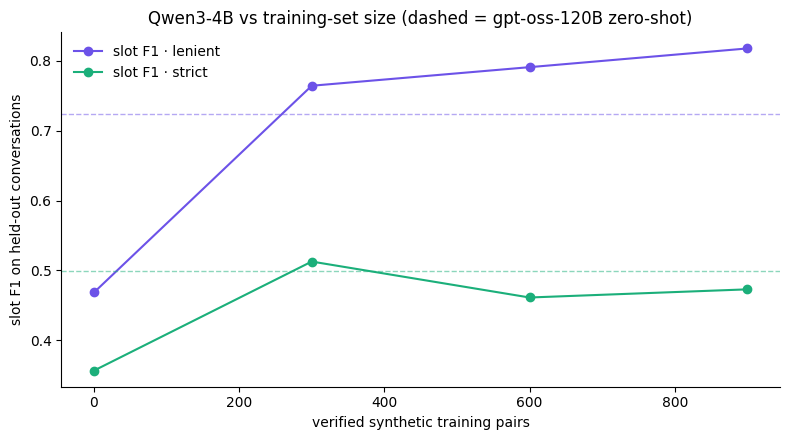

In [16]:
import matplotlib.pyplot as plt

x = [0] + TIERS
fig, ax = plt.subplots(figsize=(8, 4.5))
for metric, color in [("slot_f1_lenient", "#6c52e8"), ("slot_f1_strict", "#1baf7a")]:
    y = [curve.loc["Qwen3-4B (zero-shot)", metric]] + [curve.loc[f"+ {p} pairs", metric] for p in TIERS]
    ax.plot(x, y, "o-", color=color, label=metric.replace("slot_f1_", "slot F1 · "))
    ax.axhline(curve.loc["gpt-oss-120B (anchor)", metric], color=color, ls="--", lw=1, alpha=0.5)
ax.set_xlabel("verified synthetic training pairs")
ax.set_ylabel("slot F1 on held-out conversations")
ax.set_title("Qwen3-4B vs training-set size (dashed = gpt-oss-120B zero-shot)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [17]:
# robustness: the largest tier against the ASR-noisy variants of the same conversations
noisy = evaluate(f"{TIER_MODELS[900]}#{deployment.name}", eval_noisy)
pd.DataFrame({"tier-900 · clean": curve.loc["+ 900 pairs"], "tier-900 · ASR-noisy": noisy}).T.round(3)

  0%|          | 0/100 [00:00<?, ?it/s]

,schema_valid,slot_f1_lenient,slot_f1_strict,negation_acc
tier-900 · clean,0.99,0.818,0.473,0.679
tier-900 · ASR-noisy,0.99,0.804,0.455,0.643


### Reading the curve

| | schema-valid | lenient F1 | strict F1 | negation |
|---|---|---|---|---|
| Qwen3-4B (zero-shot) | 0.44 | 0.468 | 0.356 | 0.04 |
| + 300 pairs | 0.99 | 0.765 | 0.513 | 0.71 |
| + 600 pairs | 1.00 | 0.791 | 0.461 | 0.75 |
| + 900 pairs | 0.99 | 0.818 | 0.473 | 0.68 |
| gpt-oss-120B (anchor) | 0.95 | 0.724 | 0.499 | 0.64 |

- **300 synthetic conversations put the 4B past the 120B anchor on every metric** — lenient F1, strict F1, negation, and schema validity — and 900 pairs stretch the lenient lead to nine points, with the ASR-noisy numbers within two points of clean (0.804 vs 0.818 lenient). The tuned model reads noisy dialogue nearly as fluently as clean.
- **What saturates and what keeps climbing:** finding the right facts saturates fast — the model learns *where facts live in a conversation* from a few hundred examples. Attribute exactness (strict F1) hovers at the frontier-model level for every contender, tuned or not: getting every dose, status, and assertion simultaneously right is the hard half of this task, and it's where additional attribute-dense training data — not model scale — is the lever.

## 7. Clean up

Delete the deployment to stop GPU billing (skip this if you're keeping the endpoint up for real traffic). The datasets and fine-tuned models remain in your account, ready to redeploy.

In [18]:
for deployed in list(fw.lora.list()):
    if deployed.deployment == deployment.name:
        fw.lora.unload(deployed.name.split("/")[-1])
        print("unloaded", deployed.model)

# ignore_checks: Fireworks guards against deleting deployments with recent
# traffic — here that traffic was our own evaluation, so it's safe to skip
fw.deployments.delete(DEPLOYMENT_ID, ignore_checks=True)
print("deployment deleted — billing stopped")

unloaded accounts/andertonic/models/conversation-extractor-300
unloaded accounts/andertonic/models/conversation-extractor-600
unloaded accounts/andertonic/models/conversation-extractor-900
deployment deleted — billing stopped


## Takeaway

We fine-tuned a conversation-to-JSON extractor **without labeling a single transcript**: Fabricate generated the conversations structure-first, so the labels were projections of authored facts — grounded by exact-substring evidence, diverse by skeleton audit, and distribution-matched across splits. Three hundred of those conversations took a 4B model past a 120B zero-shot anchor on the headline metrics; nine hundred bought perfect schema validity and full robustness to ASR noise, at roughly 30× less to serve than the anchor.

To adapt this to your own domain, two things change: the extraction schema (and the system prompt that carries it) and the Fabricate generation contract that describes your conversations — vocabularies, difficulty features, and coverage targets. Everything else — the verification checks, the tier construction, the fine-tuning harness, and the evaluation — carries over unchanged.